# Mô-đun 4: Negotiation Optimization System

**Đồ án:** Hệ hỗ trợ quyết định trong định giá lương và tư vấn đàm phán lương  
**Module:** Negotiation Optimization System  
**Mục tiêu:** Prescriptive Analytics — đưa ra chiến lược đàm phán tối ưu dựa trên Expected Utility

---

## Tổng quan kiến trúc Prescriptive Analytics

```
Đầu vào: current_offer + risk_preference + kết quả Module 1/2/3
        ↓
┌──────────────────────────────────────────────────────────────┐
│  BƯỚC 1 — Salary Consensus Quantiles                        │
│  Kết hợp pred_Q* (Module 1) và peer_Q* (Module 2)          │
│  Tính Q25*, Q50*, Q75*, Q90* có trọng số                    │
├──────────────────────────────────────────────────────────────┤
│  BƯỚC 2 — Walk-away Salary (Reservation Price)              │
├──────────────────────────────────────────────────────────────┤
│  BƯỚC 3 — Target Salary (= Q75*)                            │
├──────────────────────────────────────────────────────────────┤
│  BƯỚC 4 — Candidate Salary Set (50 candidates)              │
├──────────────────────────────────────────────────────────────┤
│  BƯỚC 5 — Success Probability: Logistic Decay Model         │
├──────────────────────────────────────────────────────────────┤
│  BƯỚC 6 — Expected Utility = salary x p_success x phi_risk  │
├──────────────────────────────────────────────────────────────┤
│  BƯỚC 7 — Anchor Salary = argmax EU in [Target, Q90*]       │
├──────────────────────────────────────────────────────────────┤
│  BƯỚC 8 — Concession Ladder (5 vong dam phan)               │
├──────────────────────────────────────────────────────────────┤
│  BƯỚC 9 — Confidence Score & Explainability                 │
└──────────────────────────────────────────────────────────────┘
        ↓
Đầu ra: WalkAway, Target, Anchor, Strategy, Confidence, EU
```

## Các bước chính

1. Import thư viện và cấu hình  
2. Load / Simulate dữ liệu từ Module 1, 2, 3  
3. Bước 1: Salary Consensus Quantiles  
4. Bước 2-3: Walk-away và Target Salary  
5. Bước 4: Candidate Salary Set  
6. Bước 5: Success Probability Model  
7. Bước 6: Expected Utility (3 mức rủi ro)  
8. Bước 7: Anchor Salary — argmax EU  
9. Bước 8: Negotiation Ladder  
10. Bước 9: Confidence Score  
11. Visualization tổng hợp (8 biểu đồ)  
12. Demo Pipeline đầu đến cuối  
13. Lưu kết quả  


In [1]:
import sys
print(sys.executable)
print(sys.version)


c:\Users\AD\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


## 1. Import thư viện


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
import os
import json
from typing import Dict, List, Tuple, Optional
from scipy.special import expit          # sigmoid function

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

# ── Thư mục ───────────────────────────────────────────────────────────────────
FIGURE_DIR  = 'figure/NegotiationOpt'
OUTPUT_DIR  = 'negotiation_outputs'
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hằng số rủi ro ────────────────────────────────────────────────────────────
RISK_LEVELS  = ['LOW_RISK', 'MEDIUM_RISK', 'HIGH_RISK']
RISK_COLORS  = ['#1976d2', '#388e3c', '#d32f2f']
RISK_LABELS  = ['Thấp (Low)', 'Trung binh (Medium)', 'Cao (High)']

print("Thu vien da san sang.")
print(f"Figure dir : {FIGURE_DIR}")
print(f"Output dir : {OUTPUT_DIR}")


Thu vien da san sang.
Figure dir : figure/NegotiationOpt
Output dir : negotiation_outputs


## 2. Load dữ liệu đầu vào

Module 4 nhận đầu vào tổng hợp từ 3 module trước:

| Nguồn | Variables |
|---|---|
| **Module 1** (Salary Valuation) | `pred_Q10, pred_Q25, pred_Q50, pred_Q75, pred_Q90` |
| **Module 2** (Peer Benchmark) | `peer_Q10, peer_Q25, peer_median, peer_Q75, peer_Q90` |
| **Module 3** (Offer Assessment) | `offer_quality_label, offer_quality_probability, confidence_score` |
| **Người dùng** | `current_offer, risk_preference` |

> Nếu chưa có output từ Module 1–3, notebook tổng hợp dữ liệu mẫu realistic để minh họa đầy đủ pipeline.


In [3]:
REAL_DATA_LOADED = False

try:
    df_m1 = pd.read_csv('lgbm_predictions.csv')
    df_m2 = pd.read_csv('knn_peer_benchmark_results.csv')
    _m3_path = ('negotiation_outputs/offer_predictions.csv'
                if os.path.exists('negotiation_outputs/offer_predictions.csv')
                else 'offer_assessment_outputs/offer_predictions.csv')
    df_m3 = pd.read_csv(_m3_path)
    REAL_DATA_LOADED = True
    print("Load thanh cong ket qua tu Module 1, 2, 3.")
    print(f"   Module 1 : {df_m1.shape}")
    print(f"   Module 2 : {df_m2.shape}")
    print(f"   Module 3 : {df_m3.shape}")
except FileNotFoundError as e:
    print(f"Chua co output day du ({getattr(e, 'filename', str(e))}) -- dung du lieu mau tong hop.")

print()

if REAL_DATA_LOADED:
    n = min(len(df_m1), len(df_m2), len(df_m3))
    df_input = pd.DataFrame()
    df_input['actual_salary'] = df_m1['y_actual'].values[:n]
    df_input['pred_Q50']      = (df_m1['y_pred_p50'].values[:n]
                                 if 'y_pred_p50' in df_m1 else df_m1['y_pred'].values[:n])
    df_input['pred_Q10']      = (df_m1['y_pred_p10'].values[:n]
                                 if 'y_pred_p10' in df_m1 else df_input['pred_Q50'] * 0.78)
    df_input['pred_Q25']      = df_input['pred_Q10'] * 1.07
    df_input['pred_Q75']      = df_input['pred_Q50'] * 1.10
    df_input['pred_Q90']      = (df_m1['y_pred_p90'].values[:n]
                                 if 'y_pred_p90' in df_m1 else df_input['pred_Q50'] * 1.22)
    if 'peer_median' in df_m2.columns:
        df_input['peer_median'] = df_m2['peer_median'].values[:n]
        df_input['peer_Q10']   = df_m2['peer_min'].values[:n]
        df_input['peer_Q25']   = df_m2['peer_p25'].values[:n] if 'peer_p25' in df_m2 else df_input['peer_median'] * 0.88
        df_input['peer_Q75']   = df_m2['peer_p75'].values[:n]
        df_input['peer_Q90']   = df_m2['peer_max'].values[:n]
    else:
        df_input['peer_median'] = df_input['pred_Q50'] * np.random.uniform(0.93, 1.07, n)
        df_input['peer_Q10']   = df_input['peer_median'] * 0.78
        df_input['peer_Q25']   = df_input['peer_median'] * 0.88
        df_input['peer_Q75']   = df_input['peer_median'] * 1.12
        df_input['peer_Q90']   = df_input['peer_median'] * 1.28
    df_input['m3_confidence'] = (df_m3['confidence_score'].values[:n]
                                 if 'confidence_score' in df_m3 else 0.65)
    df_input['offer_label']   = (df_m3['decision_label'].values[:n]
                                 if 'decision_label' in df_m3 else 'FAIR')
    offer_ratios = np.random.choice([0.78, 0.85, 0.92, 1.00], size=n, p=[0.15, 0.25, 0.35, 0.25])
    df_input['current_offer'] = df_input['actual_salary'] * offer_ratios

else:
    np.random.seed(42)
    n = 3000
    base = np.random.lognormal(mean=11.2, sigma=0.55, size=n)
    base = np.clip(base, 30_000, 350_000)

    def noise(lo, hi):
        return np.random.uniform(lo, hi, n)

    df_input = pd.DataFrame({
        'actual_salary': base,
        'pred_Q10'     : base * noise(0.72, 0.80),
        'pred_Q25'     : base * noise(0.82, 0.90),
        'pred_Q50'     : base * noise(0.95, 1.05),
        'pred_Q75'     : base * noise(1.08, 1.16),
        'pred_Q90'     : base * noise(1.18, 1.30),
        'peer_Q10'     : base * noise(0.70, 0.80),
        'peer_Q25'     : base * noise(0.82, 0.90),
        'peer_median'  : base * noise(0.92, 1.08),
        'peer_Q75'     : base * noise(1.08, 1.16),
        'peer_Q90'     : base * noise(1.18, 1.32),
        'm3_confidence': np.random.uniform(0.45, 0.95, n),
        'offer_label'  : np.random.choice(['UNDERPAID','LOW','FAIR','GOOD'], n,
                                           p=[0.10, 0.20, 0.45, 0.25]),
    })
    offer_ratios = np.random.choice([0.70, 0.80, 0.88, 0.95, 1.00],
                                     size=n, p=[0.08, 0.17, 0.30, 0.30, 0.15])
    df_input['current_offer'] = base * offer_ratios

df_input['risk_preference'] = np.random.choice(RISK_LEVELS, n, p=[0.35, 0.45, 0.20])

print("=" * 60)
print("  Du lieu dau vao Module 4")
print("=" * 60)
print(f"  So ho so        : {len(df_input):,}")
print(f"  current_offer   : mean = ${df_input['current_offer'].mean():,.0f}")
print(f"  pred_Q50        : mean = ${df_input['pred_Q50'].mean():,.0f}")
print(f"  peer_median     : mean = ${df_input['peer_median'].mean():,.0f}")
print(f"  m3_confidence   : mean = {df_input['m3_confidence'].mean():.3f}")
print("=" * 60)
df_input.head(3)


Chua co output day du (offer_assessment_outputs/offer_predictions.csv) -- dung du lieu mau tong hop.

  Du lieu dau vao Module 4
  So ho so        : 3,000
  current_offer   : mean = $76,964
  pred_Q50        : mean = $86,407
  peer_median     : mean = $86,317
  m3_confidence   : mean = 0.697


,actual_salary,pred_Q10,pred_Q25,pred_Q50,pred_Q75,pred_Q90,peer_Q10,peer_Q25,peer_median,peer_Q75,peer_Q90,m3_confidence,offer_label,current_offer,risk_preference
0,96104.631093,75490.112605,80492.544402,92556.855226,109146.133136,119962.351373,71379.616859,82383.497874,101203.350594,105171.985325,115808.093383,0.549513,FAIR,96104.631093,MEDIUM_RISK
1,67775.403939,54131.224014,58093.553291,68966.974402,73483.853184,83648.159697,50305.032124,60384.142979,73108.282555,74480.339756,84444.345280,0.758377,LOW,59642.355467,LOW_RISK
2,104425.449717,77355.623327,89248.262643,105050.782366,119605.442737,128672.526700,75743.416491,86974.572362,106482.108704,116076.411230,136870.769441,0.589804,FAIR,91894.395751,MEDIUM_RISK


## 3. Bước 1 — Salary Consensus Quantiles

### Tại sao cần kết hợp Module 1 và Module 2?

- **Module 1** (RF/LGBM/XGB) dự đoán lương dựa trên 48 features — phản ánh giá trị cá nhân của ứng viên.
- **Module 2** (K-NN Peer Benchmark) cung cấp bằng chứng thực nghiệm từ thị trường lao động.

Kết hợp bằng Weighted Average:

$$Q_k^* = w_1 \cdot \text{pred}_{Q_k} + w_2 \cdot \text{peer}_{Q_k}, \quad w_1 + w_2 = 1$$

### Đánh giá 3 chiến lược trọng số

| Chiến lược | w_pred | w_peer | Phù hợp khi |
|---|---|---|---|
| Model-heavy | 0.70 | 0.30 | Mô hình có R² cao, peer group nhỏ |
| Balanced | 0.50 | 0.50 | Cân bằng hai nguồn |
| Peer-heavy | 0.30 | 0.70 | Peer group lớn, dữ liệu thị trường phong phú |

Hệ thống đánh giá và lựa chọn chiến lược theo **MAE so với actual salary**.


In [4]:
# ── 3 chien luoc trong so ─────────────────────────────────────────────────────
WEIGHT_STRATEGIES = {
    'Model-heavy' : (0.70, 0.30),
    'Balanced'    : (0.50, 0.50),
    'Peer-heavy'  : (0.30, 0.70),
}


def compute_consensus_quantiles(df, w1, w2):
    out = pd.DataFrame(index=df.index)
    out['Q25_star'] = w1 * df['pred_Q25']  + w2 * df['peer_Q25']
    out['Q50_star'] = w1 * df['pred_Q50']  + w2 * df['peer_median']
    out['Q75_star'] = w1 * df['pred_Q75']  + w2 * df['peer_Q75']
    out['Q90_star'] = w1 * df['pred_Q90']  + w2 * df['peer_Q90']
    return out


# ── Danh gia 3 chien luoc ─────────────────────────────────────────────────────
print("Danh gia chien luoc trong so:")
print("=" * 60)
print(f"  {'Chien luoc':<15} | {'w_pred':>6} | {'w_peer':>6} | {'MAE Q50*':>12}")
print("-" * 60)

strategy_evals = []
for name, (w1, w2) in WEIGHT_STRATEGIES.items():
    cq = compute_consensus_quantiles(df_input, w1, w2)
    mae_q50 = (df_input['actual_salary'] - cq['Q50_star']).abs().mean()
    strategy_evals.append({'name': name, 'w1': w1, 'w2': w2, 'mae_q50': mae_q50})
    print(f"  {name:<15} | {w1:>6.2f} | {w2:>6.2f} | {mae_q50:>12,.0f}")

print("=" * 60)

# ── Chon chien luoc toi uu ────────────────────────────────────────────────────
best_strategy = min(strategy_evals, key=lambda x: x['mae_q50'])
W1_STAR = best_strategy['w1']
W2_STAR = best_strategy['w2']

print(f"\nChien luoc tot nhat: {best_strategy['name']}  (w1={W1_STAR}, w2={W2_STAR})")
print(f"  MAE Q50* vs actual: ${best_strategy['mae_q50']:,.0f}")

# ── Consensus quantiles voi trong so toi uu ───────────────────────────────────
cq = compute_consensus_quantiles(df_input, W1_STAR, W2_STAR)
df_input['Q25_star'] = cq['Q25_star']
df_input['Q50_star'] = cq['Q50_star']
df_input['Q75_star'] = cq['Q75_star']
df_input['Q90_star'] = cq['Q90_star']

print(f"\nConsensus Quantiles (w1={W1_STAR}, w2={W2_STAR}):")
for col in ['Q25_star', 'Q50_star', 'Q75_star', 'Q90_star']:
    print(f"  {col:<12}: mean = ${df_input[col].mean():>10,.0f}")


Danh gia chien luoc trong so:
  Chien luoc      | w_pred | w_peer |     MAE Q50*
------------------------------------------------------------
  Model-heavy     |   0.70 |   0.30 |        1,759
  Balanced        |   0.50 |   0.50 |        1,948
  Peer-heavy      |   0.30 |   0.70 |        2,459

Chien luoc tot nhat: Model-heavy  (w1=0.7, w2=0.3)
  MAE Q50* vs actual: $1,759

Consensus Quantiles (w1=0.7, w2=0.3):
  Q25_star    : mean = $    74,221
  Q50_star    : mean = $    86,380
  Q75_star    : mean = $    96,676
  Q90_star    : mean = $   107,433


## 4. Bước 2 & 3 — Walk-away Salary và Target Salary

### Walk-away Salary (Reservation Price)

Mức lương tối thiểu chấp nhận. Nếu offer thấp hơn: **từ chối**.

$$\text{WalkAway} = \max(Q_{25}^*, \max(\text{pred}_{Q10}, \text{peer}_{Q10}))$$

Dùng `max` để WalkAway không thấp hơn sàn tuyệt đối của cả hai nguồn.

### Target Salary

$$\text{Target} = Q_{75}^*$$

> **Lý do chọn Q75*:** 75% thị trường không vượt qua mức này — vừa tham vọng, vừa khả thi.


In [5]:
def compute_walkaway_target(row):
    absolute_floor = max(row['pred_Q10'], row['peer_Q10'])
    walkaway       = max(row['Q25_star'], absolute_floor)
    target         = row['Q75_star']
    return walkaway, target


results_wt = df_input.apply(compute_walkaway_target, axis=1)
df_input['walkaway_salary'] = [r[0] for r in results_wt]
df_input['target_salary']   = [r[1] for r in results_wt]

valid_wt = (
    (df_input['walkaway_salary'] < df_input['target_salary']) &
    (df_input['target_salary']   < df_input['Q90_star'])
)

print("=" * 60)
print("  Walk-away & Target Salary Summary")
print("=" * 60)
print(f"  Walk-away mean : ${df_input['walkaway_salary'].mean():>12,.0f}")
print(f"  Target mean    : ${df_input['target_salary'].mean():>12,.0f}")
print(f"  Q90* mean      : ${df_input['Q90_star'].mean():>12,.0f}")
print("-" * 60)
print(f"  Ty le ho so thoa WalkAway < Target < Q90*: {valid_wt.mean()*100:.1f}%")
print(f"  Gap Target - WalkAway : ${(df_input['target_salary'] - df_input['walkaway_salary']).mean():>8,.0f} (mean)")
print("=" * 60)

n_reject = (df_input['current_offer'] < df_input['walkaway_salary']).sum()
print(f"\n  Offer duoi Walk-away (nen tu choi): {n_reject:,} / {n:,}  ({n_reject/n*100:.1f}%)")


  Walk-away & Target Salary Summary
  Walk-away mean : $      74,221
  Target mean    : $      96,676
  Q90* mean      : $     107,433
------------------------------------------------------------
  Ty le ho so thoa WalkAway < Target < Q90*: 100.0%
  Gap Target - WalkAway : $  22,456 (mean)

  Offer duoi Walk-away (nen tu choi): 881 / 3,000  (29.4%)


## 5. Bước 4 — Candidate Salary Set

Sinh 50 mức lương ứng viên từ `WalkAway` đến `Q90*`:
- **Đoạn 1** [WalkAway, Target]: 40% điểm — vùng an toàn, xác suất thành công cao
- **Đoạn 2** [Target, Q90*]: 60% điểm — vùng tham vọng, xác suất thành công thấp hơn


In [6]:
N_CANDIDATES = 50


def generate_candidates(walkaway, target, q90, n_total=N_CANDIDATES):
    n_safe  = int(n_total * 0.40)
    n_ambit = n_total - n_safe
    seg1 = np.linspace(walkaway, target, n_safe  + 1)[:-1]
    seg2 = np.linspace(target,   q90,   n_ambit + 1)
    return np.unique(np.concatenate([seg1, seg2]))


all_candidates = []
for _, row in df_input.iterrows():
    cands = generate_candidates(
        row['walkaway_salary'], row['target_salary'], row['Q90_star']
    )
    all_candidates.append(cands)
df_input['n_candidates'] = [len(c) for c in all_candidates]

print("=" * 60)
print("  Candidate Salary Set Summary")
print("=" * 60)
desc = df_input['n_candidates'].describe()
print(f"  N candidates: min={int(desc['min'])}, median={int(desc['50%'])}, max={int(desc['max'])}")
ex = all_candidates[0]
print(f"  Vi du (ho so dau): [{ex[0]:,.0f}, ..., {ex[len(ex)//2]:,.0f}, ..., {ex[-1]:,.0f}]")
print(f"  WalkAway = ${df_input['walkaway_salary'].iloc[0]:,.0f}")
print(f"  Target   = ${df_input['target_salary'].iloc[0]:,.0f}")
print(f"  Q90*     = ${df_input['Q90_star'].iloc[0]:,.0f}")
print("=" * 60)


  Candidate Salary Set Summary
  N candidates: min=51, median=51, max=51
  Vi du (ho so dau): [81,060, ..., 109,748, ..., 118,716]
  WalkAway = $81,060
  Target   = $107,954
  Q90*     = $118,716


## 6. Bước 5 — Mô hình Xác suất Thành công

### Logistic Decay Model

$$p_{\text{success}}(s) = \frac{1}{1 + e^{k \cdot \frac{s - Q_{50}^*}{Q_{90}^* - Q_{10}^*}}}$$

- Tại $s = Q_{50}^*$: $p = 0.5$
- Tại $s \leq Q_{25}^*$: $p \approx 0.85$ (cao)
- Tại $s \geq Q_{90}^*$: $p \approx 0.10$ (thấp)

### Steepness k theo Risk Level

| Risk Level | k | Đặc điểm |
|---|---|---|
| LOW_RISK | 3.5 | Dốc — ưu tiên xác suất thành công |
| MEDIUM_RISK | 2.5 | Cân bằng |
| HIGH_RISK | 1.5 | Thoải — chấp nhận rủi ro để đổi lương cao hơn |


In [7]:
# Steepness k theo muc rui ro
STEEPNESS = {
    'LOW_RISK'    : 3.5,
    'MEDIUM_RISK' : 2.5,
    'HIGH_RISK'   : 1.5,
}

# Gioi han xac suat [p_min, p_max] theo muc rui ro
P_BOUNDS = {
    'LOW_RISK'    : (0.15, 0.90),
    'MEDIUM_RISK' : (0.10, 0.88),
    'HIGH_RISK'   : (0.05, 0.85),
}


def success_probability(salary, q10, q50, q90, risk_level='MEDIUM_RISK'):
    k    = STEEPNESS[risk_level]
    span = max(q90 - q10, 1.0)
    z    = k * (salary - q50) / span
    p    = expit(-z)
    p_min, p_max = P_BOUNDS[risk_level]
    return float(np.clip(p, p_min, p_max))


def success_probability_array(salaries, q10, q50, q90, risk_level='MEDIUM_RISK'):
    k    = STEEPNESS[risk_level]
    span = max(q90 - q10, 1.0)
    z    = k * (salaries - q50) / span
    p    = expit(-z)
    p_min, p_max = P_BOUNDS[risk_level]
    return np.clip(p, p_min, p_max)


print("Mo hinh Success Probability da san sang.")
print()

# Vi du minh hoa voi ho so trung binh
ex_q10 = df_input['Q25_star'].mean()
ex_q50 = df_input['Q50_star'].mean()
ex_q90 = df_input['Q90_star'].mean()

print(f"Vi du voi Q50*=${ex_q50:,.0f}, Q90*=${ex_q90:,.0f}:")
print(f"  {'Salary':>10} | {'p_LOW':>8} | {'p_MED':>8} | {'p_HIGH':>8}")
print("-" * 45)
for s in [ex_q10, ex_q50, ex_q90]:
    ps = {r: success_probability(s, ex_q10, ex_q50, ex_q90, r) for r in RISK_LEVELS}
    print(f"  ${s:>9,.0f} | {ps['LOW_RISK']:>8.3f} | {ps['MEDIUM_RISK']:>8.3f} | {ps['HIGH_RISK']:>8.3f}")


Mo hinh Success Probability da san sang.

Vi du voi Q50*=$86,380, Q90*=$107,433:
      Salary |    p_LOW |    p_MED |   p_HIGH
---------------------------------------------
  $   74,221 |    0.783 |    0.714 |    0.634
  $   86,380 |    0.500 |    0.500 |    0.500
  $  107,433 |    0.150 |    0.170 |    0.279


## 7. Bước 6 — Expected Utility

$$EU(s, \text{risk}) = s \cdot p_{\text{success}}(s) \cdot \phi(s, \text{risk})$$

**Risk Adjustment Factor** $\phi$:

| Risk Level | phi(s) | Ý nghĩa |
|---|---|---|
| LOW_RISK | $1 - 0.3 \times \max\!\left(\frac{s - Q_{50}^*}{Q_{90}^* - Q_{50}^*}, 0\right)$ | Phạt mạnh khi vượt Q50* |
| MEDIUM_RISK | 1.0 | Không điều chỉnh |
| HIGH_RISK | $1 + 0.2 \times \max\!\left(\frac{s - Q_{50}^*}{Q_{90}^* - Q_{50}^*}, 0\right)$ | Thưởng khi đề xuất cao |


In [8]:
def risk_adjustment(salary, q50, q90, risk_level):
    span     = max(q90 - q50, 1.0)
    relative = (salary - q50) / span

    if risk_level == 'LOW_RISK':
        phi = 1.0 - 0.30 * max(relative, 0)
        return float(np.clip(phi, 0.60, 1.0))
    elif risk_level == 'HIGH_RISK':
        phi = 1.0 + 0.20 * max(relative, 0)
        return float(np.clip(phi, 1.0, 1.30))
    else:
        return 1.0


def expected_utility_array(salaries, q10, q50, q90, risk_level):
    p_arr = success_probability_array(salaries, q10, q50, q90, risk_level)
    phi   = np.array([risk_adjustment(s, q50, q90, risk_level) for s in salaries])
    return salaries * p_arr * phi


print("Expected Utility Function da san sang.")
print()

# Tinh EU cho toan bo dataset
eu_records = []
for i, row in df_input.iterrows():
    cands  = all_candidates[i - df_input.index[0]]
    risk   = row['risk_preference']
    q10    = row['Q25_star']
    q50    = row['Q50_star']
    q90    = row['Q90_star']
    eu_arr = expected_utility_array(cands, q10, q50, q90, risk)
    best_i = np.argmax(eu_arr)
    eu_records.append({
        'best_eu_salary'  : cands[best_i],
        'best_eu_value'   : eu_arr[best_i],
        'best_eu_norm'    : float(eu_arr[best_i] / (eu_arr.max() + 1e-10)),
        'best_p_success'  : success_probability(cands[best_i], q10, q50, q90, risk),
    })

eu_df    = pd.DataFrame(eu_records, index=df_input.index)
df_input = pd.concat([df_input, eu_df], axis=1)

print("=" * 60)
print("  Expected Utility -- Thong ke theo Risk Level")
print("=" * 60)
for risk in RISK_LEVELS:
    mask = df_input['risk_preference'] == risk
    sub  = df_input[mask]
    print(f"  {risk:<15}: n={mask.sum():>5,} | EU Salary=${sub['best_eu_salary'].mean():>10,.0f} | p={sub['best_p_success'].mean():.3f}")
print("=" * 60)


Expected Utility Function da san sang.

  Expected Utility -- Thong ke theo Risk Level
  LOW_RISK       : n=1,074 | EU Salary=$    73,668 | p=0.778
  MEDIUM_RISK    : n=1,338 | EU Salary=$    75,128 | p=0.714
  HIGH_RISK      : n=  588 | EU Salary=$    73,188 | p=0.632


## 8. Bước 7 — Anchor Salary

Anchor Salary là **mức mở đầu đàm phán**. Theo lý thuyết *Anchoring Effect*, mức đề xuất đầu tiên neo giữ toàn bộ cuộc đàm phán.

$$\text{Anchor} = \arg\max_{s \in [\text{Target},\, Q_{90}^*]} EU(s)$$

Ràng buộc $s \geq \text{Target}$ đảm bảo Anchor luôn cao hơn mức mong muốn, tạo không gian nhượng bộ.


In [9]:
def compute_anchor(walkaway, target, q90, q10, q50, risk_level, n_fine=200):
    s_range = np.linspace(target, q90, n_fine)
    eu_arr  = expected_utility_array(s_range, q10, q50, q90, risk_level)
    eu_norm = eu_arr / (eu_arr.max() + 1e-10)
    best_i  = np.argmax(eu_arr)
    anchor  = float(s_range[best_i])
    return {
        'anchor_salary'     : anchor,
        'eu_at_anchor'      : float(eu_arr[best_i]),
        'p_at_anchor'       : float(success_probability(anchor, q10, q50, q90, risk_level)),
        'norm_eu_at_anchor' : float(eu_norm[best_i]),
        'salary_range'      : s_range,
        'eu_curve'          : eu_arr,
        'eu_norm_curve'     : eu_norm,
    }


# Tinh Anchor cho toan bo dataset
anchor_records = []
for i, row in df_input.iterrows():
    res = compute_anchor(
        walkaway   = row['walkaway_salary'],
        target     = row['target_salary'],
        q90        = row['Q90_star'],
        q10        = row['Q25_star'],
        q50        = row['Q50_star'],
        risk_level = row['risk_preference'],
    )
    anchor_records.append({
        'anchor_salary'     : res['anchor_salary'],
        'eu_at_anchor'      : res['eu_at_anchor'],
        'p_at_anchor'       : res['p_at_anchor'],
        'norm_eu_at_anchor' : res['norm_eu_at_anchor'],
    })

anchor_df = pd.DataFrame(anchor_records, index=df_input.index)
df_input  = pd.concat([df_input, anchor_df], axis=1)

print("=" * 60)
print("  Anchor Salary -- Ket qua")
print("=" * 60)
for risk in RISK_LEVELS:
    mask  = df_input['risk_preference'] == risk
    sub   = df_input[mask]
    ratio = sub['anchor_salary'] / sub['target_salary']
    print(f"  {risk:<15}: Anchor=${sub['anchor_salary'].mean():>10,.0f}  (Anc/Tgt={ratio.mean():.3f})")
print("=" * 60)

valid_anchor = (df_input['anchor_salary'] >= df_input['target_salary'] - 1)
print(f"\n  Anchor >= Target: {valid_anchor.mean()*100:.1f}%")


  Anchor Salary -- Ket qua
  LOW_RISK       : Anchor=$    95,934  (Anc/Tgt=1.000)
  MEDIUM_RISK    : Anchor=$    97,867  (Anc/Tgt=1.000)
  HIGH_RISK      : Anchor=$    95,323  (Anc/Tgt=1.000)

  Anchor >= Target: 100.0%


## 9. Bước 8 — Chiến lược Nhượng bộ (Negotiation Ladder)

### Mô hình nhượng bộ 5 vòng

```
Vong 1: Anchor (mo dau cao)
Vong 2: Anchor - X% x (Anchor - Target)
Vong 3: Anchor - Y% x (Anchor - Target)
Vong 4: Anchor - Z% x (Anchor - Target)
Vong 5: Target
Fallback: WalkAway
```

| Risk | Tốc độ nhượng bộ | Giải thích |
|---|---|---|
| LOW_RISK | Nhanh (45/70/88%) | Muốn chốt sớm |
| MEDIUM_RISK | Vừa (38/62/82%) | Cân bằng |
| HIGH_RISK | Chậm (28/52/76%) | Sẵn sàng kéo dài |


In [10]:
CONCESSION_RATES = {
    'LOW_RISK'    : [0.00, 0.45, 0.70, 0.88, 1.00],
    'MEDIUM_RISK' : [0.00, 0.38, 0.62, 0.82, 1.00],
    'HIGH_RISK'   : [0.00, 0.28, 0.52, 0.76, 1.00],
}
ROUND_NAMES = ['Vong 1 (Anchor)', 'Vong 2', 'Vong 3', 'Vong 4', 'Vong 5 (Target)']


def generate_concession_ladder(anchor, target, walkaway, risk_level):
    rates  = CONCESSION_RATES[risk_level]
    gap    = anchor - target
    rounds = [round(anchor - rate * gap, -2) for rate in rates]
    rounds[-1] = round(target, -2)
    fallback   = round(walkaway, -2)
    return {
        'risk_level'  : risk_level,
        'rounds'      : rounds,
        'fallback'    : fallback,
        'total_steps' : rounds + [fallback],
        'gap'         : gap,
    }


# Tinh ladder cho toan bo dataset
ladder_records = []
for _, row in df_input.iterrows():
    ladder = generate_concession_ladder(
        anchor    = row['anchor_salary'],
        target    = row['target_salary'],
        walkaway  = row['walkaway_salary'],
        risk_level= row['risk_preference'],
    )
    rec = {'fallback': ladder['fallback']}
    for j, rnd in enumerate(ladder['rounds']):
        rec[f'round_{j+1}'] = rnd
    ladder_records.append(rec)

ladder_df = pd.DataFrame(ladder_records, index=df_input.index)
df_input  = pd.concat([df_input, ladder_df], axis=1)

# In vi du voi 3 muc rui ro
print("=" * 65)
print("  Vi du Negotiation Ladder (Anchor=115K, Target=95K, WalkAway=78K)")
print("=" * 65)
for risk in RISK_LEVELS:
    ladder = generate_concession_ladder(115_000, 95_000, 78_000, risk)
    print(f"\n  {risk}:")
    for name, sal in zip(ROUND_NAMES, ladder['rounds']):
        print(f"    {name:<25}: ${sal:>10,.0f}")
    print(f"    {'Fallback (WalkAway)':<25}: ${ladder['fallback']:>10,.0f}")
print("=" * 65)


  Vi du Negotiation Ladder (Anchor=115K, Target=95K, WalkAway=78K)

  LOW_RISK:
    Vong 1 (Anchor)          : $   115,000
    Vong 2                   : $   106,000
    Vong 3                   : $   101,000
    Vong 4                   : $    97,400
    Vong 5 (Target)          : $    95,000
    Fallback (WalkAway)      : $    78,000

  MEDIUM_RISK:
    Vong 1 (Anchor)          : $   115,000
    Vong 2                   : $   107,400
    Vong 3                   : $   102,600
    Vong 4                   : $    98,600
    Vong 5 (Target)          : $    95,000
    Fallback (WalkAway)      : $    78,000

  HIGH_RISK:
    Vong 1 (Anchor)          : $   115,000
    Vong 2                   : $   109,400
    Vong 3                   : $   104,600
    Vong 4                   : $    99,800
    Vong 5 (Target)          : $    95,000
    Fallback (WalkAway)      : $    78,000


## 10. Bước 9 — Confidence Score

Tổng hợp từ 4 nguồn:

$$\text{Confidence} = 0.30 \cdot c_{M3} + 0.25 \cdot c_{\text{dist}} + 0.30 \cdot p_{\text{anchor}} + 0.15 \cdot c_{\text{consensus}}$$

| Thành phần | Trọng số | Ý nghĩa |
|---|---|---|
| Module 3 confidence | 30% | Độ chắc chắn đánh giá offer |
| Khoảng cách Anchor đến Q90* | 25% | Anchor xa Q90* → khả thi hơn |
| p_success tại Anchor | 30% | Xác suất thành công tại mức mở đầu |
| Consensus tightness | 15% | Khoảng hẹp → hai nguồn đồng thuận cao |


In [11]:
def compute_confidence(row):
    c_m3      = float(row.get('m3_confidence', 0.60))
    q90       = row['Q90_star']
    q25       = row['Q25_star']
    anchor    = row['anchor_salary']
    span_full = max(q90 - q25, 1.0)
    c_dist    = float(np.clip((q90 - anchor) / span_full, 0, 1))
    p_anchor  = float(row['p_at_anchor'])
    span_iqr  = max(row['Q75_star'] - row['Q25_star'], 1.0)
    ref_span  = row['Q50_star'] * 0.50
    c_cons    = float(np.clip(1 - span_iqr / ref_span, 0, 1))

    score = 0.30 * c_m3 + 0.25 * c_dist + 0.30 * p_anchor + 0.15 * c_cons
    score = float(np.clip(score, 0, 1))
    level = 'HIGH' if score >= 0.65 else ('MEDIUM' if score >= 0.40 else 'LOW')
    return score, level


conf_results              = df_input.apply(compute_confidence, axis=1)
df_input['confidence_score'] = [r[0] for r in conf_results]
df_input['confidence_level'] = [r[1] for r in conf_results]

print("=" * 60)
print("  Confidence Score Summary")
print("=" * 60)
for lvl, marker in zip(['HIGH', 'MEDIUM', 'LOW'], ['[CAO]', '[TRUNG BINH]', '[THAP]']):
    cnt = (df_input['confidence_level'] == lvl).sum()
    pct = cnt / n * 100
    print(f"  {marker:<15} {lvl:<8}: {cnt:>5,}  ({pct:.1f}%)")
print("-" * 60)
print(f"  Mean score : {df_input['confidence_score'].mean():.4f}")
print(f"  Std score  : {df_input['confidence_score'].std():.4f}")
print("=" * 60)


  Confidence Score Summary
  [CAO]           HIGH    :     0  (0.0%)
  [TRUNG BINH]    MEDIUM  : 2,434  (81.1%)
  [THAP]          LOW     :   566  (18.9%)
------------------------------------------------------------
  Mean score : 0.4535
  Std score  : 0.0566


## 11. Visualization tổng hợp


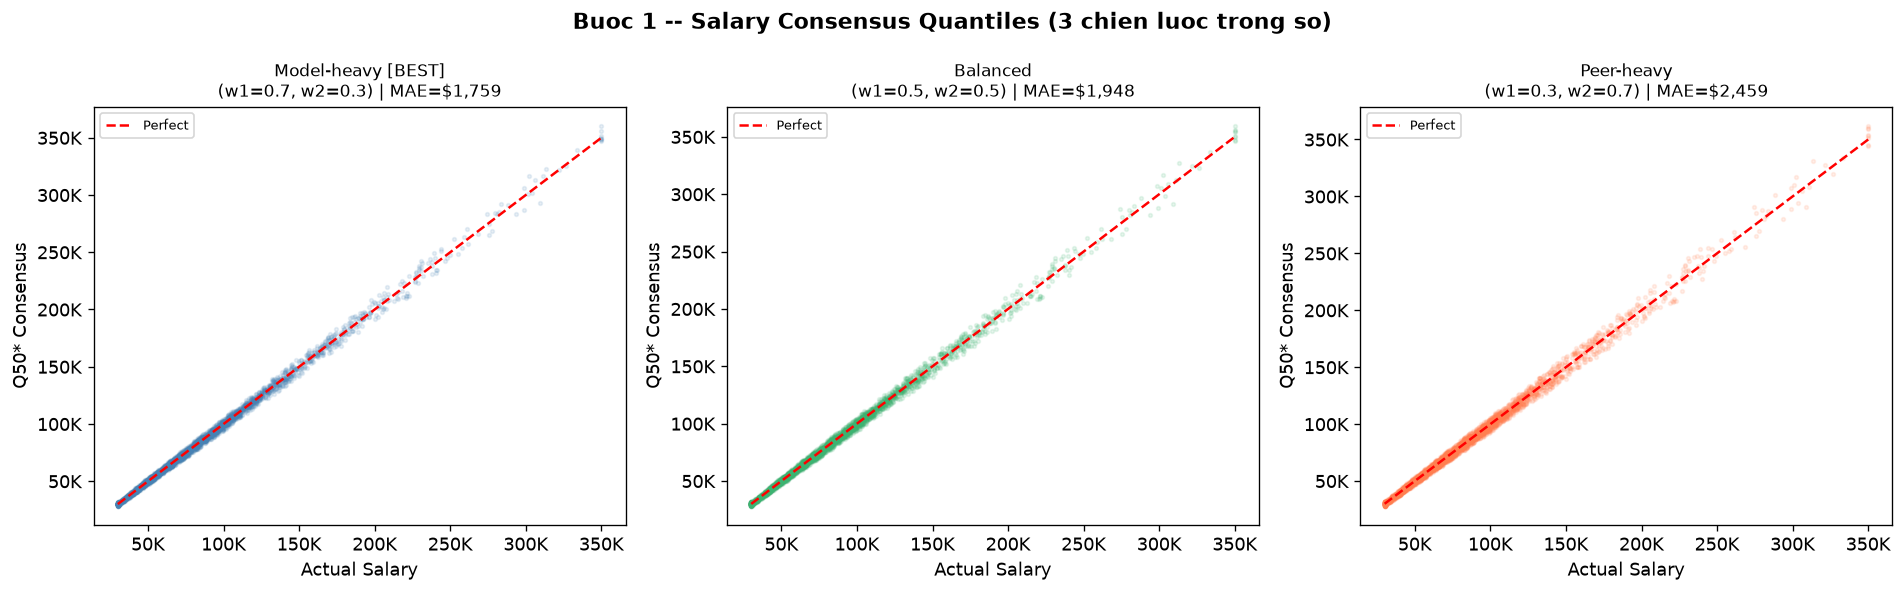

Da luu: figure/NegotiationOpt/01_consensus_quantiles.png


In [12]:
# ── VIZ 1: Consensus Quantiles ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Buoc 1 -- Salary Consensus Quantiles (3 chien luoc trong so)', fontsize=13, fontweight='bold')

clrs = ['steelblue', 'mediumseagreen', 'coral']
for ax_idx, (strategy_info, ax) in enumerate(zip(strategy_evals, axes)):
    name = strategy_info['name']
    w1, w2 = strategy_info['w1'], strategy_info['w2']
    cq_tmp = compute_consensus_quantiles(df_input, w1, w2)
    ax.scatter(df_input['actual_salary'], cq_tmp['Q50_star'],
               alpha=0.12, s=5, color=clrs[ax_idx])
    lims = [df_input['actual_salary'].min(), df_input['actual_salary'].max()]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
    mae_val = (df_input['actual_salary'] - cq_tmp['Q50_star']).abs().mean()
    star = ' [BEST]' if name == best_strategy['name'] else ''
    ax.set_title(f"{name}{star}\n(w1={w1}, w2={w2}) | MAE=${mae_val:,.0f}", fontsize=10)
    ax.set_xlabel('Actual Salary')
    ax.set_ylabel('Q50* Consensus')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/01_consensus_quantiles.png', bbox_inches='tight')
plt.show()
print(f"Da luu: {FIGURE_DIR}/01_consensus_quantiles.png")


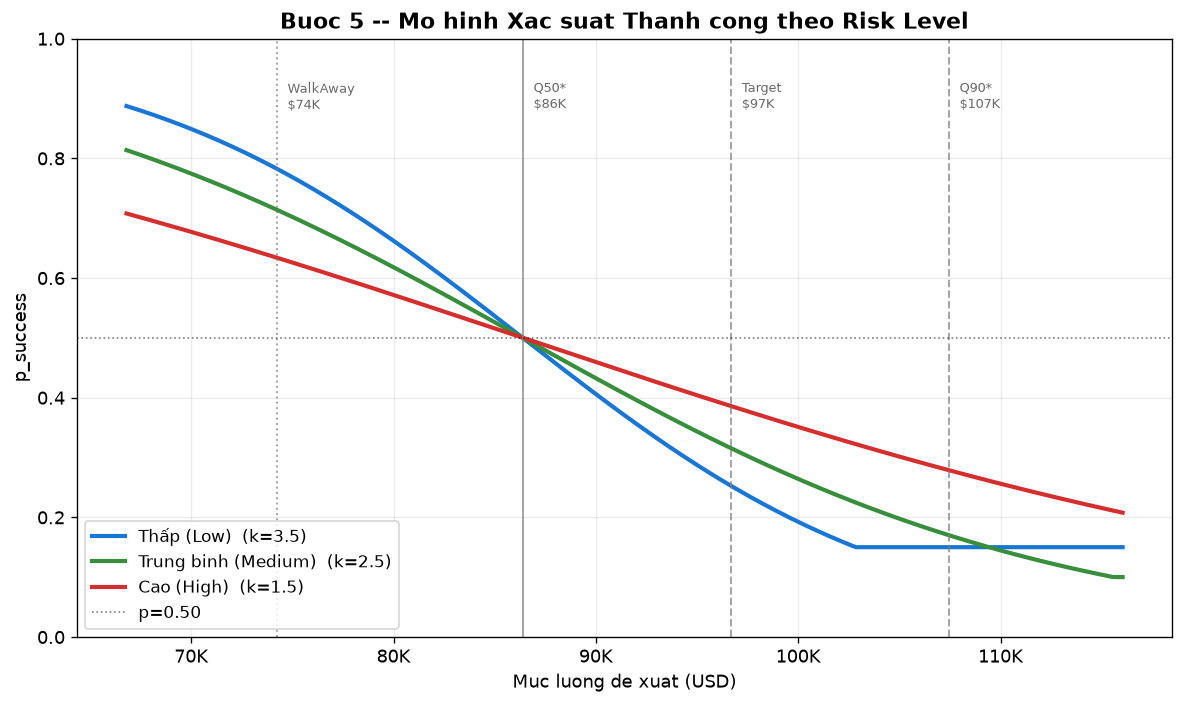

Da luu: figure/NegotiationOpt/02_success_probability.png


In [13]:
# ── VIZ 2: Success Probability Curves ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ex_q10 = df_input['Q25_star'].mean()
ex_q50 = df_input['Q50_star'].mean()
ex_q90 = df_input['Q90_star'].mean()
ex_wa  = df_input['walkaway_salary'].mean()
ex_tgt = df_input['target_salary'].mean()
s_range = np.linspace(ex_wa * 0.90, ex_q90 * 1.08, 300)

for risk, color, label in zip(RISK_LEVELS, RISK_COLORS, RISK_LABELS):
    p_arr = success_probability_array(s_range, ex_q10, ex_q50, ex_q90, risk)
    ax.plot(s_range, p_arr, color=color, linewidth=2.5, label=f'{label}  (k={STEEPNESS[risk]})')

for sal, name, ls in [
    (ex_wa,  'WalkAway', ':'),
    (ex_tgt, 'Target',   '--'),
    (ex_q50, 'Q50*',     '-'),
    (ex_q90, 'Q90*',     '--'),
]:
    ax.axvline(sal, color='gray', linestyle=ls, linewidth=1.2, alpha=0.7)
    ax.text(sal + ex_q90*0.005, 0.93, f'{name}\n${sal/1000:.0f}K',
            fontsize=8, color='dimgray', va='top')

ax.axhline(0.50, color='black', linestyle=':', linewidth=1.0, alpha=0.5, label='p=0.50')
ax.set_xlabel('Muc luong de xuat (USD)')
ax.set_ylabel('p_success')
ax.set_title('Buoc 5 -- Mo hinh Xac suat Thanh cong theo Risk Level', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/02_success_probability.png', bbox_inches='tight')
plt.show()
print(f"Da luu: {FIGURE_DIR}/02_success_probability.png")


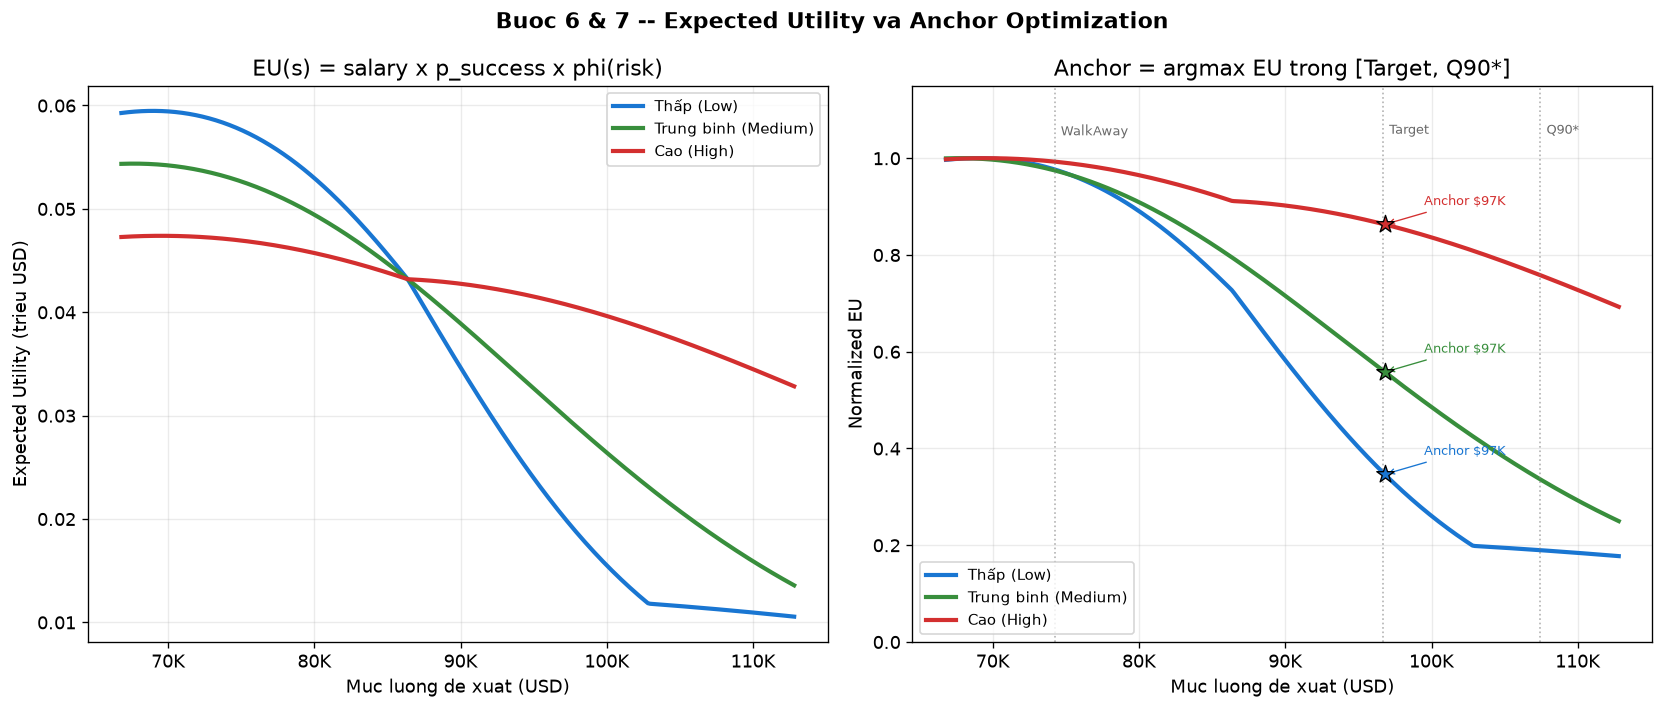

Da luu: figure/NegotiationOpt/03_utility_optimization.png


In [14]:
# ── VIZ 3 & 4: Utility Curves + Anchor Optimization ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Buoc 6 & 7 -- Expected Utility va Anchor Optimization', fontsize=13, fontweight='bold')

s_range = np.linspace(ex_wa * 0.90, ex_q90 * 1.05, 300)

# Panel 1: EU raw curves
for risk, color, label in zip(RISK_LEVELS, RISK_COLORS, RISK_LABELS):
    eu = expected_utility_array(s_range, ex_q10, ex_q50, ex_q90, risk)
    axes[0].plot(s_range, eu / 1e6, color=color, linewidth=2.5, label=label)

axes[0].set_xlabel('Muc luong de xuat (USD)')
axes[0].set_ylabel('Expected Utility (trieu USD)')
axes[0].set_title('EU(s) = salary x p_success x phi(risk)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

# Panel 2: Normalized EU voi anchor markers
for risk, color, label in zip(RISK_LEVELS, RISK_COLORS, RISK_LABELS):
    eu      = expected_utility_array(s_range, ex_q10, ex_q50, ex_q90, risk)
    eu_norm = eu / eu.max()
    axes[1].plot(s_range, eu_norm, color=color, linewidth=2.5, label=label)
    tgt_range = s_range[s_range >= ex_tgt]
    eu_tgt    = expected_utility_array(tgt_range, ex_q10, ex_q50, ex_q90, risk)
    best_s    = tgt_range[np.argmax(eu_tgt)]
    best_norm = eu_tgt.max() / eu.max()
    axes[1].scatter(best_s, best_norm, color=color, s=120, zorder=6,
                    marker='*', edgecolors='black', linewidths=0.8)
    axes[1].annotate(f'Anchor ${best_s/1000:.0f}K',
                     xy=(best_s, best_norm),
                     xytext=(best_s + ex_q90*0.025, best_norm + 0.04),
                     fontsize=7.5, color=color,
                     arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

for sal, name in [(ex_wa, 'WalkAway'), (ex_tgt, 'Target'), (ex_q90, 'Q90*')]:
    axes[1].axvline(sal, color='gray', linestyle=':', linewidth=1.0, alpha=0.6)
    axes[1].text(sal + ex_q90*0.004, 1.07, name, fontsize=7.5, color='dimgray', va='top')

axes[1].set_xlabel('Muc luong de xuat (USD)')
axes[1].set_ylabel('Normalized EU')
axes[1].set_title('Anchor = argmax EU trong [Target, Q90*]')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)
axes[1].set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/03_utility_optimization.png', bbox_inches='tight')
plt.show()
print(f"Da luu: {FIGURE_DIR}/03_utility_optimization.png")


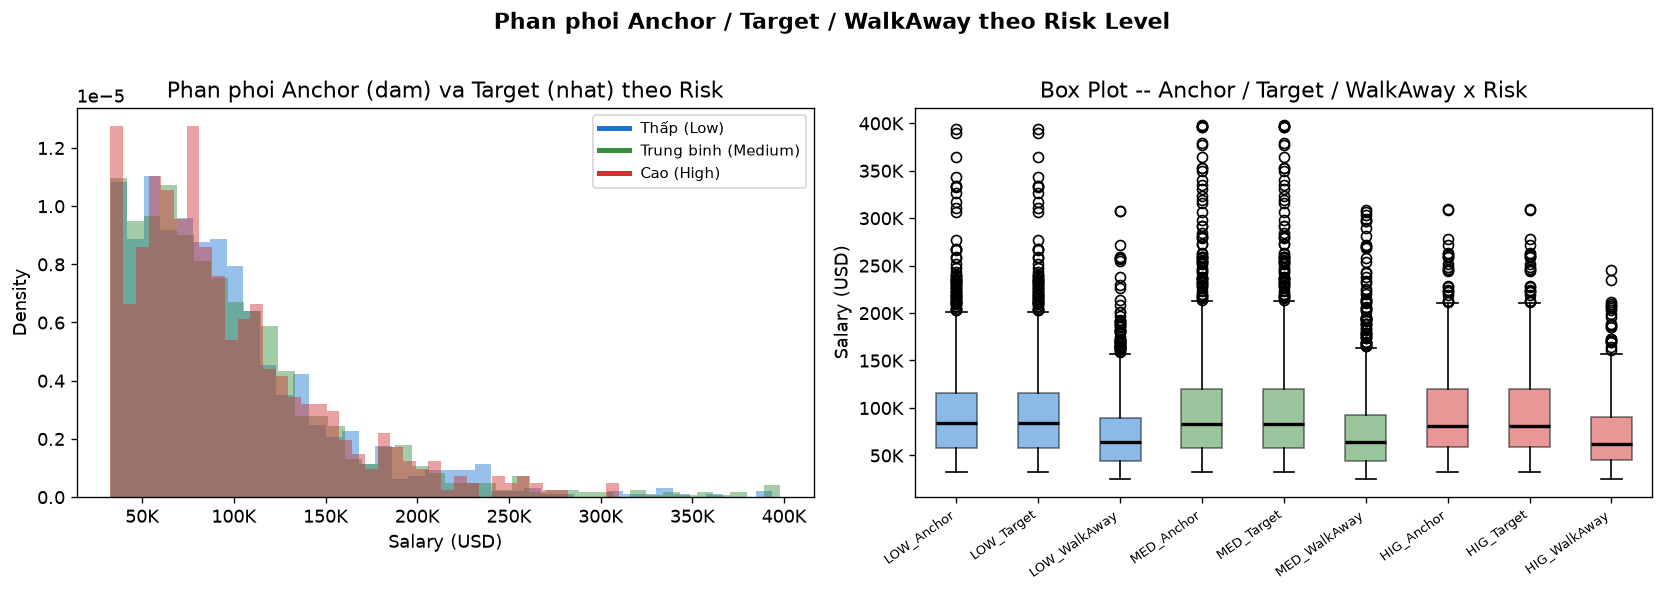

Da luu: figure/NegotiationOpt/04_anchor_target_walkaway.png


In [15]:
# ── VIZ 5: Phan phoi Anchor / Target / WalkAway ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phan phoi Anchor / Target / WalkAway theo Risk Level', fontsize=13, fontweight='bold')

for risk, color in zip(RISK_LEVELS, RISK_COLORS):
    mask = df_input['risk_preference'] == risk
    axes[0].hist(df_input[mask]['anchor_salary'], bins=40, color=color, alpha=0.35, density=True)
    axes[0].hist(df_input[mask]['target_salary'], bins=40, color=color, alpha=0.15, density=True)

for risk, color, label in zip(RISK_LEVELS, RISK_COLORS, RISK_LABELS):
    axes[0].plot([], [], color=color, linewidth=3, label=label)
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Density')
axes[0].set_title('Phan phoi Anchor (dam) va Target (nhat) theo Risk')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=9)

# Box plot
plot_data, plot_labels, plot_colors = [], [], []
for risk, color in zip(RISK_LEVELS, RISK_COLORS):
    mask = df_input['risk_preference'] == risk
    short = risk[:3]
    for col, lbl in [('anchor_salary', f'{short}_Anchor'),
                     ('target_salary', f'{short}_Target'),
                     ('walkaway_salary', f'{short}_WalkAway')]:
        plot_data.append(df_input[mask][col].values)
        plot_labels.append(lbl)
        plot_colors.append(color)

bp = axes[1].boxplot(plot_data, patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[1].set_xticklabels(plot_labels, rotation=35, ha='right', fontsize=7.5)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].set_title('Box Plot -- Anchor / Target / WalkAway x Risk')
axes[1].set_ylabel('Salary (USD)')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/04_anchor_target_walkaway.png', bbox_inches='tight')
plt.show()
print(f"Da luu: {FIGURE_DIR}/04_anchor_target_walkaway.png")


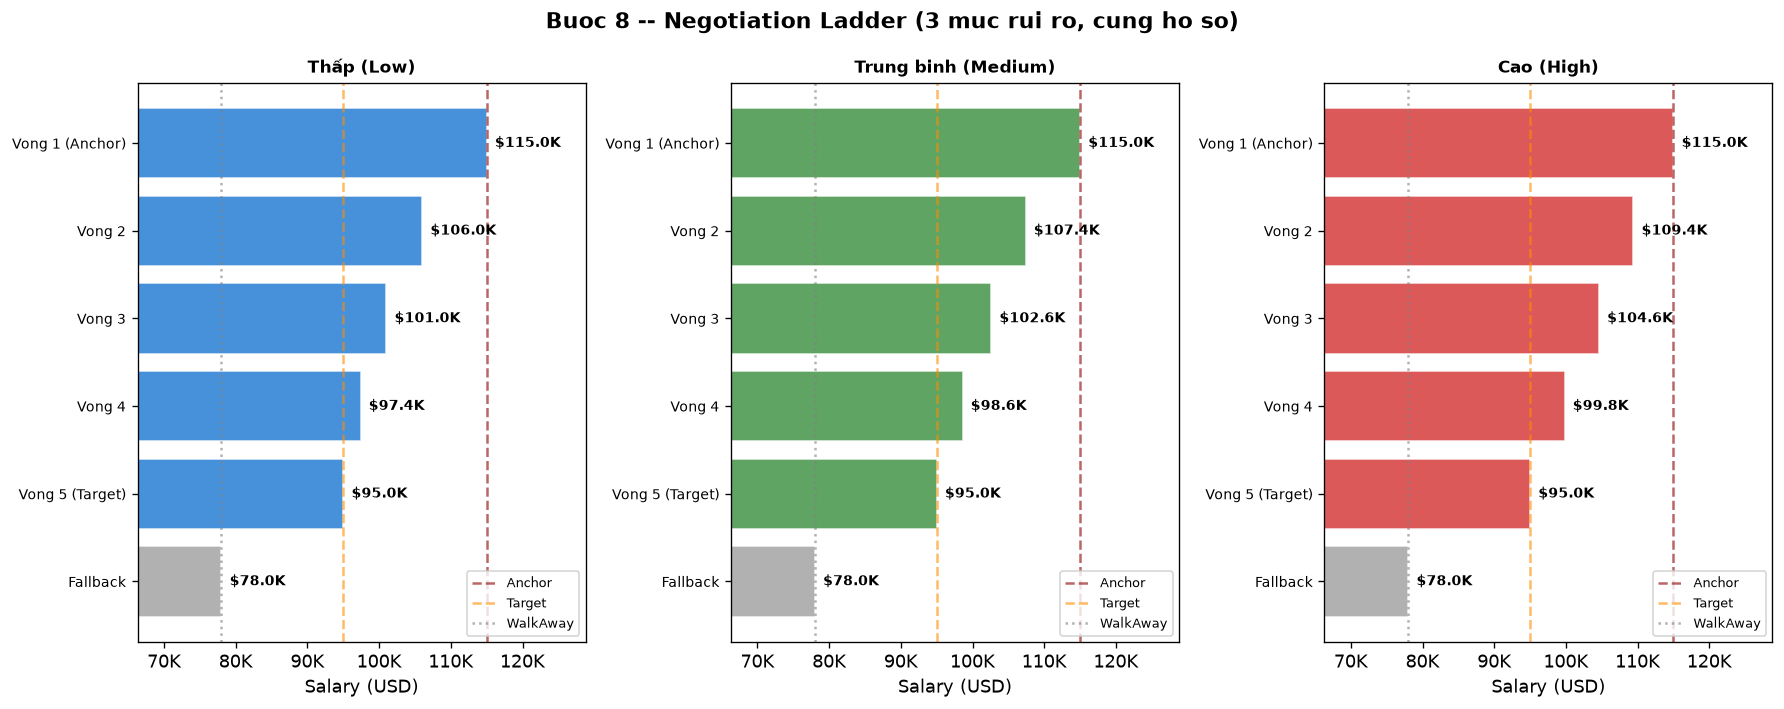

Da luu: figure/NegotiationOpt/05_negotiation_ladder.png


In [16]:
# ── VIZ 6: Negotiation Ladder (3 kich ban) ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Buoc 8 -- Negotiation Ladder (3 muc rui ro, cung ho so)', fontsize=13, fontweight='bold')

anchor_ex   = 115_000
target_ex   = 95_000
walkaway_ex = 78_000

for ax, risk, color, label in zip(axes, RISK_LEVELS, RISK_COLORS, RISK_LABELS):
    ladder    = generate_concession_ladder(anchor_ex, target_ex, walkaway_ex, risk)
    all_steps = ladder['rounds'] + [ladder['fallback']]
    s_labels  = ROUND_NAMES + ['Fallback']
    clrs_bar  = [color] * 5 + ['#9e9e9e']

    bars = ax.barh(range(len(all_steps)), all_steps, color=clrs_bar, alpha=0.80, edgecolor='white')
    for bar_obj, sal in zip(bars, all_steps):
        ax.text(bar_obj.get_width() + anchor_ex * 0.01,
                bar_obj.get_y() + bar_obj.get_height() / 2,
                f'${sal/1000:.1f}K', va='center', fontsize=8.5, fontweight='bold')

    ax.axvline(anchor_ex,   color='darkred',    linestyle='--', linewidth=1.5, alpha=0.6, label='Anchor')
    ax.axvline(target_ex,   color='darkorange', linestyle='--', linewidth=1.5, alpha=0.6, label='Target')
    ax.axvline(walkaway_ex, color='gray',       linestyle=':',  linewidth=1.5, alpha=0.6, label='WalkAway')
    ax.set_yticks(range(len(all_steps)))
    ax.set_yticklabels(s_labels, fontsize=8.5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Salary (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.invert_yaxis()
    ax.legend(fontsize=7.5, loc='lower right')
    ax.set_xlim(walkaway_ex * 0.85, anchor_ex * 1.12)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/05_negotiation_ladder.png', bbox_inches='tight')
plt.show()
print(f"Da luu: {FIGURE_DIR}/05_negotiation_ladder.png")


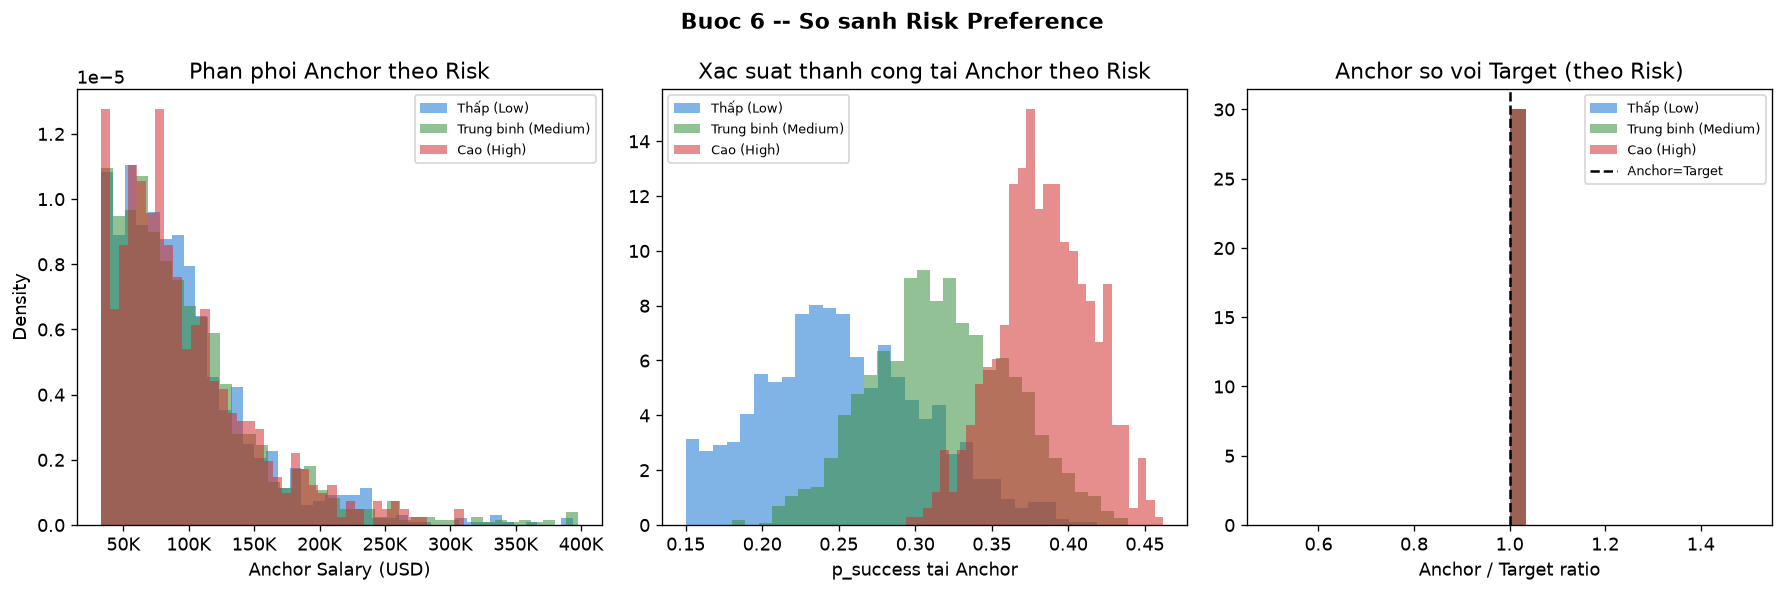

Da luu: figure/NegotiationOpt/06_risk_comparison.png


In [17]:
# ── VIZ 7: Risk Comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Buoc 6 -- So sanh Risk Preference', fontsize=13, fontweight='bold')

for risk, color, label in zip(RISK_LEVELS, RISK_COLORS, RISK_LABELS):
    mask = df_input['risk_preference'] == risk
    axes[0].hist(df_input[mask]['anchor_salary'], bins=40, color=color, alpha=0.55,
                 label=label, density=True)
axes[0].set_xlabel('Anchor Salary (USD)')
axes[0].set_ylabel('Density')
axes[0].set_title('Phan phoi Anchor theo Risk')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=8)

for risk, color, label in zip(RISK_LEVELS, RISK_COLORS, RISK_LABELS):
    mask = df_input['risk_preference'] == risk
    axes[1].hist(df_input[mask]['p_at_anchor'], bins=30, color=color, alpha=0.55,
                 label=label, density=True)
axes[1].set_xlabel('p_success tai Anchor')
axes[1].set_title('Xac suat thanh cong tai Anchor theo Risk')
axes[1].legend(fontsize=8)

for risk, color, label in zip(RISK_LEVELS, RISK_COLORS, RISK_LABELS):
    mask  = df_input['risk_preference'] == risk
    ratio = df_input[mask]['anchor_salary'] / df_input[mask]['target_salary']
    axes[2].hist(ratio, bins=30, color=color, alpha=0.55, label=label, density=True)
axes[2].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='Anchor=Target')
axes[2].set_xlabel('Anchor / Target ratio')
axes[2].set_title('Anchor so voi Target (theo Risk)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/06_risk_comparison.png', bbox_inches='tight')
plt.show()
print(f"Da luu: {FIGURE_DIR}/06_risk_comparison.png")


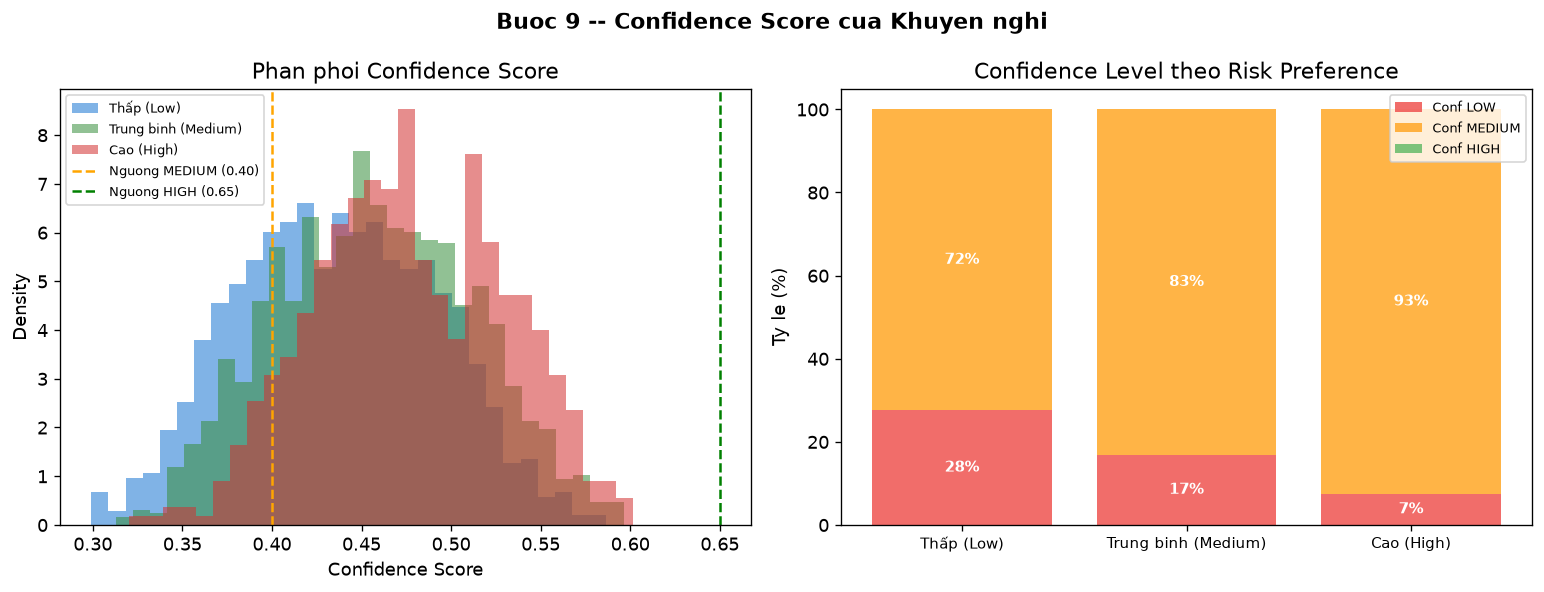

Da luu: figure/NegotiationOpt/07_confidence_distribution.png


In [18]:
# ── VIZ 8: Confidence Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Buoc 9 -- Confidence Score cua Khuyen nghi', fontsize=13, fontweight='bold')

for risk, color, label in zip(RISK_LEVELS, RISK_COLORS, RISK_LABELS):
    mask = df_input['risk_preference'] == risk
    axes[0].hist(df_input[mask]['confidence_score'], bins=30, color=color,
                 alpha=0.55, label=label, density=True)
axes[0].axvline(0.40, color='orange', linestyle='--', linewidth=1.5, label='Nguong MEDIUM (0.40)')
axes[0].axvline(0.65, color='green',  linestyle='--', linewidth=1.5, label='Nguong HIGH (0.65)')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Phan phoi Confidence Score')
axes[0].legend(fontsize=8)

conf_by_risk = pd.crosstab(df_input['risk_preference'], df_input['confidence_level'])
conf_by_risk = conf_by_risk.reindex(columns=['LOW','MEDIUM','HIGH'], fill_value=0)
conf_pct     = conf_by_risk.div(conf_by_risk.sum(axis=1), axis=0) * 100

bar_clrs = ['#ef5350', '#ffa726', '#66bb6a']
bottom   = np.zeros(len(RISK_LEVELS))
x        = np.arange(len(RISK_LEVELS))
for col, bc in zip(['LOW','MEDIUM','HIGH'], bar_clrs):
    vals = conf_pct.reindex(RISK_LEVELS)[col].fillna(0).values
    axes[1].bar(x, vals, bottom=bottom, color=bc, alpha=0.85, label=f'Conf {col}')
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            axes[1].text(xi, b + v/2, f'{v:.0f}%', ha='center', va='center',
                         fontsize=9, fontweight='bold', color='white')
    bottom += vals

axes[1].set_xticks(x)
axes[1].set_xticklabels(RISK_LABELS, fontsize=9)
axes[1].set_ylabel('Ty le (%)')
axes[1].set_title('Confidence Level theo Risk Preference')
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/07_confidence_distribution.png', bbox_inches='tight')
plt.show()
print(f"Da luu: {FIGURE_DIR}/07_confidence_distribution.png")


## 12. Demo: Pipeline đầu đến cuối cho hồ sơ mới


In [19]:
def run_negotiation_optimizer(
    current_offer, pred_Q10, pred_Q25, pred_Q50, pred_Q75, pred_Q90,
    peer_Q10, peer_Q25, peer_median, peer_Q75, peer_Q90,
    risk_preference='MEDIUM_RISK', m3_confidence=0.65, offer_label='FAIR',
    w1=None, w2=None, verbose=True,
):
    if w1 is None:
        w1, w2 = W1_STAR, W2_STAR

    # Buoc 1: Consensus Quantiles
    row = pd.Series({
        'pred_Q25': pred_Q25, 'pred_Q50': pred_Q50,
        'pred_Q75': pred_Q75, 'pred_Q90': pred_Q90, 'pred_Q10': pred_Q10,
        'peer_Q25': peer_Q25, 'peer_median': peer_median,
        'peer_Q75': peer_Q75, 'peer_Q90': peer_Q90, 'peer_Q10': peer_Q10,
        'm3_confidence': m3_confidence, 'offer_label': offer_label,
    })
    cq = compute_consensus_quantiles(pd.DataFrame([row]), w1, w2).iloc[0]
    q25_s, q50_s, q75_s, q90_s = cq['Q25_star'], cq['Q50_star'], cq['Q75_star'], cq['Q90_star']

    # Buoc 2 & 3
    row['Q25_star'] = q25_s; row['Q50_star'] = q50_s
    row['Q75_star'] = q75_s; row['Q90_star'] = q90_s
    walkaway, target = compute_walkaway_target(row)

    # Buoc 4
    candidates = generate_candidates(walkaway, target, q90_s)

    # Buoc 5 & 6
    eu_arr   = expected_utility_array(candidates, q25_s, q50_s, q90_s, risk_preference)
    p_arr    = success_probability_array(candidates, q25_s, q50_s, q90_s, risk_preference)
    eu_norm  = eu_arr / (eu_arr.max() + 1e-10)

    # Buoc 7
    anchor_res  = compute_anchor(walkaway, target, q90_s, q25_s, q50_s, risk_preference)
    anchor      = anchor_res['anchor_salary']
    eu_anchor   = anchor_res['eu_at_anchor']
    p_anchor    = anchor_res['p_at_anchor']

    # Buoc 8
    ladder = generate_concession_ladder(anchor, target, walkaway, risk_preference)

    # Buoc 9
    row['anchor_salary'] = anchor
    row['p_at_anchor']   = p_anchor
    conf_score, conf_level = compute_confidence(row)

    result = {
        'walk_away_salary'      : walkaway,
        'target_salary'         : target,
        'anchor_salary'         : anchor,
        'success_probability'   : p_anchor,
        'expected_utility'      : eu_anchor,
        'risk_level'            : risk_preference,
        'confidence_score'      : conf_score,
        'confidence_level'      : conf_level,
        'Q25_star': q25_s, 'Q50_star': q50_s, 'Q75_star': q75_s, 'Q90_star': q90_s,
        'negotiation_rounds'    : ladder['rounds'],
        'fallback_salary'       : ladder['fallback'],
        'offer_vs_walkaway'     : current_offer - walkaway,
        'offer_vs_target'       : current_offer - target,
        'anchor_gap_to_target'  : anchor - target,
        'anchor_gap_to_offer'   : anchor - current_offer,
        'candidate_salaries'    : candidates.tolist(),
        'eu_curve'              : eu_arr.tolist(),
        'p_success_curve'       : p_arr.tolist(),
        'current_offer'         : current_offer,
        'weight_pred'           : w1,
        'weight_peer'           : w2,
    }
    if verbose:
        _print_report(result)
    return result


def _print_report(r):
    wa = r['walk_away_salary']; tgt = r['target_salary']; anc = r['anchor_salary']
    print("=" * 68)
    print("  NEGOTIATION OPTIMIZATION REPORT")
    print("=" * 68)
    print(f"  Current Offer   : ${r['current_offer']:>12,.0f}")
    print(f"  Risk Level      : {r['risk_level']}")
    print(f"  Confidence      : {r['confidence_score']:.3f}  [{r['confidence_level']}]")
    print()
    print(f"  -- Salary Consensus (w_pred={r['weight_pred']}, w_peer={r['weight_peer']}) --")
    for k, v in [('Q25*', r['Q25_star']), ('Q50*', r['Q50_star']),
                 ('Q75*', r['Q75_star']), ('Q90*', r['Q90_star'])]:
        print(f"  {k}: ${v:>12,.0f}")
    print()
    print(f"  -- Chien luoc Dam phan --")
    print(f"  Walk-away : ${wa:>12,.0f}  <- tu choi neu offer < muc nay")
    print(f"  Target    : ${tgt:>12,.0f}  <- muc mong muon hop ly")
    print(f"  Anchor    : ${anc:>12,.0f}  <- muc mo dau dam phan")
    print()
    print(f"  p_success @ Anchor : {r['success_probability']:.3f}")
    print(f"  Expected Utility   : ${r['expected_utility']:>12,.0f}")
    print()
    print(f"  -- Negotiation Ladder --")
    for name, sal in zip(ROUND_NAMES, r['negotiation_rounds']):
        print(f"  {name:<25}: ${sal:>12,.0f}")
    print(f"  {'Fallback (WalkAway)':<25}: ${r['fallback_salary']:>12,.0f}")
    print()
    print(f"  -- Phan tich Offer --")
    for label, val in [
        ('Offer vs WalkAway', r['offer_vs_walkaway']),
        ('Offer vs Target',   r['offer_vs_target']),
    ]:
        sign = '+' if val >= 0 else ''
        print(f"  {label:<20}: {sign}${val:>10,.0f}  ({sign}{val/r['current_offer']*100:.1f}%)")
    print(f"  Khong gian dam phan (Anchor - Offer): ${r['anchor_gap_to_offer']:>8,.0f}")
    print("=" * 68)


In [20]:
DEMO_PROFILE = dict(
    current_offer  = 88_000,
    pred_Q10=70_000, pred_Q25=80_000, pred_Q50=95_000,
    pred_Q75=112_000, pred_Q90=130_000,
    peer_Q10=67_000, peer_Q25=78_000, peer_median=92_000,
    peer_Q75=108_000, peer_Q90=126_000,
    m3_confidence=0.72, offer_label='LOW',
)

for risk in RISK_LEVELS:
    print(f"\n{'='*68}")
    print(f"  KICH BAN: {risk}")
    r = run_negotiation_optimizer(**DEMO_PROFILE, risk_preference=risk)



  KICH BAN: LOW_RISK
  NEGOTIATION OPTIMIZATION REPORT
  Current Offer   : $      88,000
  Risk Level      : LOW_RISK
  Confidence      : 0.427  [MEDIUM]

  -- Salary Consensus (w_pred=0.7, w_peer=0.3) --
  Q25*: $      79,400
  Q50*: $      94,100
  Q75*: $     110,800
  Q90*: $     128,800

  -- Chien luoc Dam phan --
  Walk-away : $      79,400  <- tu choi neu offer < muc nay
  Target    : $     110,800  <- muc mong muon hop ly
  Anchor    : $     110,800  <- muc mo dau dam phan

  p_success @ Anchor : 0.234
  Expected Utility   : $      22,229

  -- Negotiation Ladder --
  Vong 1 (Anchor)          : $     110,800
  Vong 2                   : $     110,800
  Vong 3                   : $     110,800
  Vong 4                   : $     110,800
  Vong 5 (Target)          : $     110,800
  Fallback (WalkAway)      : $      79,400

  -- Phan tich Offer --
  Offer vs WalkAway   : +$     8,600  (+9.8%)
  Offer vs Target     : $   -22,800  (-25.9%)
  Khong gian dam phan (Anchor - Offer): $ 

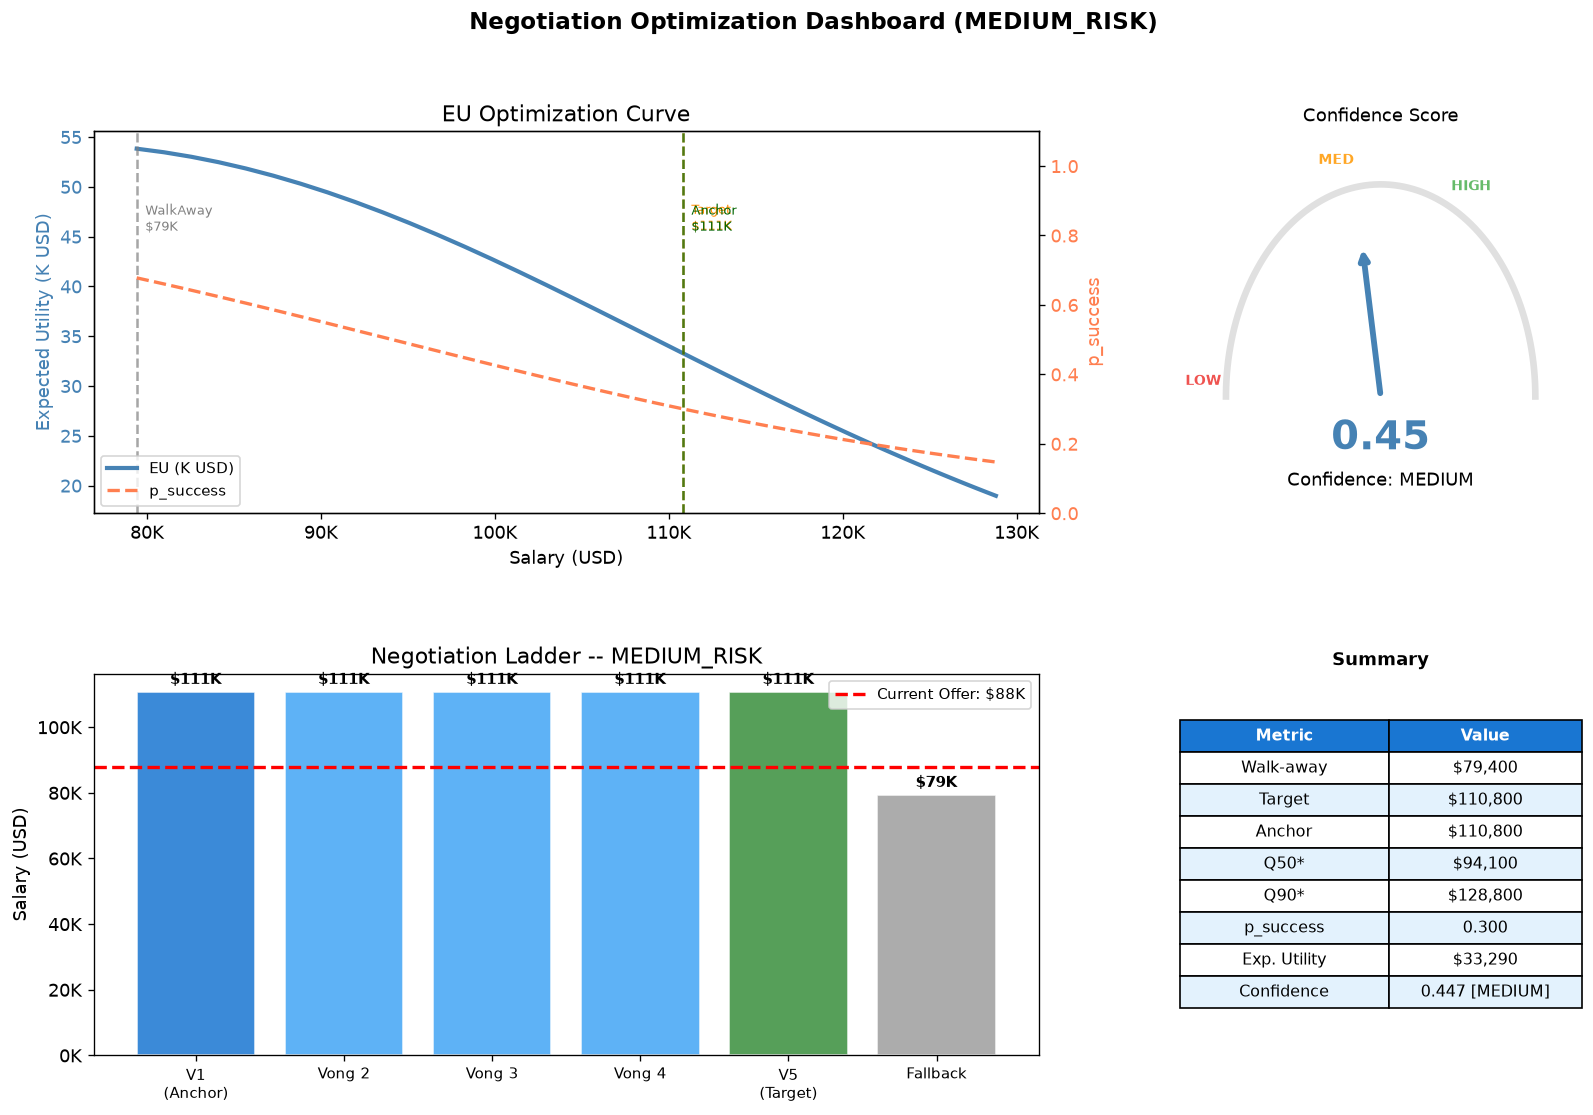

Da luu: figure/NegotiationOpt/08_dashboard.png


In [21]:
# ── Dashboard tong hop cho Demo (MEDIUM_RISK) ─────────────────────────────────
result_demo = run_negotiation_optimizer(**DEMO_PROFILE, risk_preference='MEDIUM_RISK', verbose=False)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
fig.suptitle('Negotiation Optimization Dashboard (MEDIUM_RISK)', fontsize=14, fontweight='bold')

# Panel 1: EU Optimization Curve
ax1 = fig.add_subplot(gs[0, :2])
s_demo  = np.array(result_demo['candidate_salaries'])
eu_demo = np.array(result_demo['eu_curve'])
p_demo  = np.array(result_demo['p_success_curve'])

ax1.plot(s_demo, eu_demo / 1e3, color='steelblue', linewidth=2.5, label='EU (K USD)')
ax1_r = ax1.twinx()
ax1_r.plot(s_demo, p_demo, color='coral', linewidth=2, linestyle='--', label='p_success')
ax1_r.set_ylabel('p_success', color='coral')
ax1_r.tick_params(axis='y', labelcolor='coral')
ax1_r.set_ylim(0, 1.1)

for sal, name, col in [
    (result_demo['walk_away_salary'], 'WalkAway', 'gray'),
    (result_demo['target_salary'],   'Target',   'darkorange'),
    (result_demo['anchor_salary'],   'Anchor',   'darkgreen'),
]:
    ax1.axvline(sal, color=col, linestyle='--', linewidth=1.5, alpha=0.7)
    ypos = (eu_demo.max() / 1e3) * 0.90
    ax1.text(sal + (s_demo.max() - s_demo.min()) * 0.01, ypos, f'{name}\n${sal/1000:.0f}K',
             fontsize=8, color=col, va='top')

ax1.set_xlabel('Salary (USD)')
ax1.set_ylabel('Expected Utility (K USD)', color='steelblue')
ax1.set_title('EU Optimization Curve')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.tick_params(axis='y', labelcolor='steelblue')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_r.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')

# Panel 2: Gauge Confidence
ax2 = fig.add_subplot(gs[0, 2])
conf = result_demo['confidence_score']
theta = np.linspace(0, np.pi, 200)
ax2.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=4, alpha=0.12)
conf_theta = np.pi * (1 - conf)
ax2.annotate('', xy=(0.72 * np.cos(conf_theta), 0.72 * np.sin(conf_theta)),
             xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='steelblue', lw=3.5))
ax2.text(0, -0.20, f'{conf:.2f}', ha='center', va='center',
         fontsize=24, fontweight='bold', color='steelblue')
ax2.text(0, -0.42, f'Confidence: {result_demo["confidence_level"]}',
         ha='center', fontsize=11)
for pct, lbl, col in [(0.02, 'LOW', '#ef5350'), (0.42, 'MED', '#ffa726'), (0.67, 'HIGH', '#66bb6a')]:
    a = np.pi * (1 - pct)
    ax2.text(1.15 * np.cos(a), 1.15 * np.sin(a), lbl, ha='center',
             va='center', fontsize=8.5, color=col, fontweight='bold')
ax2.set_xlim(-1.3, 1.3); ax2.set_ylim(-0.55, 1.25); ax2.axis('off')
ax2.set_title('Confidence Score', fontsize=11)

# Panel 3: Negotiation Ladder
ax3 = fig.add_subplot(gs[1, :2])
rounds_val = result_demo['negotiation_rounds'] + [result_demo['fallback_salary']]
step_names = ['V1\n(Anchor)', 'Vong 2', 'Vong 3', 'Vong 4', 'V5\n(Target)', 'Fallback']
clrs_lad   = ['#1976d2'] + ['#42a5f5'] * 3 + ['#388e3c', '#9e9e9e']

bars = ax3.bar(range(len(rounds_val)), rounds_val, color=clrs_lad, alpha=0.85, edgecolor='white')
ax3.axhline(result_demo['current_offer'], color='red', linestyle='--', linewidth=2,
            label=f"Current Offer: ${result_demo['current_offer']/1000:.0f}K")
for bar_obj, val in zip(bars, rounds_val):
    ax3.text(bar_obj.get_x() + bar_obj.get_width() / 2,
             bar_obj.get_height() + result_demo['Q90_star'] * 0.01,
             f'${val/1000:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_xticks(range(len(step_names)))
ax3.set_xticklabels(step_names, fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax3.set_ylabel('Salary (USD)')
ax3.set_title('Negotiation Ladder -- MEDIUM_RISK')
ax3.legend(fontsize=9)

# Panel 4: Summary table
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')
summary_data = [
    ['Walk-away',    f"${result_demo['walk_away_salary']:,.0f}"],
    ['Target',       f"${result_demo['target_salary']:,.0f}"],
    ['Anchor',       f"${result_demo['anchor_salary']:,.0f}"],
    ['Q50*',         f"${result_demo['Q50_star']:,.0f}"],
    ['Q90*',         f"${result_demo['Q90_star']:,.0f}"],
    ['p_success',    f"{result_demo['success_probability']:.3f}"],
    ['Exp. Utility', f"${result_demo['expected_utility']:,.0f}"],
    ['Confidence',   f"{result_demo['confidence_score']:.3f} [{result_demo['confidence_level']}]"],
]
tbl = ax4.table(
    cellText=summary_data, colLabels=['Metric', 'Value'],
    cellLoc='center', loc='center', colWidths=[0.52, 0.48]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)
for (ri, ci), cell in tbl.get_celld().items():
    if ri == 0:
        cell.set_facecolor('#1976d2')
        cell.set_text_props(color='white', fontweight='bold')
    elif ri % 2 == 0:
        cell.set_facecolor('#e3f2fd')
ax4.set_title('Summary', fontsize=11, fontweight='bold', pad=5)

plt.savefig(f'{FIGURE_DIR}/08_dashboard.png', bbox_inches='tight')
plt.show()
print(f"Da luu: {FIGURE_DIR}/08_dashboard.png")


## 13. Lưu kết quả


In [22]:
# ── Luu optimizer config ──────────────────────────────────────────────────────
optimizer_config = {
    'W1_STAR'         : W1_STAR,
    'W2_STAR'         : W2_STAR,
    'best_strategy'   : best_strategy['name'],
    'STEEPNESS'       : STEEPNESS,
    'P_BOUNDS'        : {k: list(v) for k, v in P_BOUNDS.items()},
    'CONCESSION_RATES': CONCESSION_RATES,
    'N_CANDIDATES'    : N_CANDIDATES,
}
joblib.dump(optimizer_config, f'{OUTPUT_DIR}/negotiation_optimizer.pkl')
print(f"Da luu: {OUTPUT_DIR}/negotiation_optimizer.pkl")

# ── Luu recommendations ───────────────────────────────────────────────────────
recom_cols = [
    'risk_preference', 'current_offer',
    'Q25_star', 'Q50_star', 'Q75_star', 'Q90_star',
    'walkaway_salary', 'target_salary', 'anchor_salary',
    'p_at_anchor', 'eu_at_anchor', 'norm_eu_at_anchor',
    'confidence_score', 'confidence_level',
    'round_1', 'round_2', 'round_3', 'round_4', 'round_5', 'fallback',
]
recom_exist = [c for c in recom_cols if c in df_input.columns]
df_input[recom_exist].to_csv(f'{OUTPUT_DIR}/negotiation_recommendations.csv', index=False)
print(f"Da luu: {OUTPUT_DIR}/negotiation_recommendations.csv")

# ── Luu salary candidates (vi du dien hinh) ───────────────────────────────────
med_idx  = (df_input['Q50_star'] - df_input['Q50_star'].median()).abs().idxmin()
arr_pos  = med_idx - df_input.index[0]
ex_cands = all_candidates[arr_pos]
ex_row   = df_input.loc[med_idx]
ex_eu    = expected_utility_array(ex_cands,
               ex_row['Q25_star'], ex_row['Q50_star'],
               ex_row['Q90_star'], ex_row['risk_preference'])
ex_p     = success_probability_array(ex_cands,
               ex_row['Q25_star'], ex_row['Q50_star'],
               ex_row['Q90_star'], ex_row['risk_preference'])

pd.DataFrame({
    'salary'             : ex_cands,
    'expected_utility'   : ex_eu,
    'success_probability': ex_p,
    'eu_normalized'      : ex_eu / (ex_eu.max() + 1e-10),
}).to_csv(f'{OUTPUT_DIR}/salary_candidates.csv', index=False)
print(f"Da luu: {OUTPUT_DIR}/salary_candidates.csv")

# ── Luu utility scores ────────────────────────────────────────────────────────
util_cols = ['risk_preference', 'Q50_star', 'anchor_salary',
             'eu_at_anchor', 'norm_eu_at_anchor', 'p_at_anchor']
util_exist = [c for c in util_cols if c in df_input.columns]
df_input[util_exist].to_csv(f'{OUTPUT_DIR}/utility_scores.csv', index=False)
print(f"Da luu: {OUTPUT_DIR}/utility_scores.csv")

# ── Luu success probabilities (curve data) ────────────────────────────────────
sp_data = []
q10_m = df_input['Q25_star'].mean()
q50_m = df_input['Q50_star'].mean()
q90_m = df_input['Q90_star'].mean()
for risk in RISK_LEVELS:
    s_arr = np.linspace(q10_m * 0.80, q90_m * 1.10, 100)
    p_arr = success_probability_array(s_arr, q10_m, q50_m, q90_m, risk)
    for s, p in zip(s_arr, p_arr):
        sp_data.append({'risk_level': risk, 'salary': s, 'p_success': p})
pd.DataFrame(sp_data).to_csv(f'{OUTPUT_DIR}/success_probabilities.csv', index=False)
print(f"Da luu: {OUTPUT_DIR}/success_probabilities.csv")

# ── Luu metrics tong hop ──────────────────────────────────────────────────────
metrics = {
    'n_profiles'     : int(len(df_input)),
    'weight_strategy': best_strategy['name'],
    'w1_pred'        : W1_STAR,
    'w2_peer'        : W2_STAR,
    'anchor_by_risk' : {
        risk: {
            'mean_anchor'    : float(df_input[df_input['risk_preference']==risk]['anchor_salary'].mean()),
            'mean_target'    : float(df_input[df_input['risk_preference']==risk]['target_salary'].mean()),
            'mean_p_success' : float(df_input[df_input['risk_preference']==risk]['p_at_anchor'].mean()),
            'mean_confidence': float(df_input[df_input['risk_preference']==risk]['confidence_score'].mean()),
        } for risk in RISK_LEVELS
    },
    'confidence_distribution': df_input['confidence_level'].value_counts().to_dict(),
}
with open(f'{OUTPUT_DIR}/negotiation_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"Da luu: {OUTPUT_DIR}/negotiation_metrics.json")

print()
print("=" * 65)
print("  Tom tat Module 4 -- Negotiation Optimization System")
print("=" * 65)
print(f"  Chien luoc trong so  : {best_strategy['name']}  (w1={W1_STAR}, w2={W2_STAR})")
print(f"  Tong ho so da toi uu : {len(df_input):,}")
for risk in RISK_LEVELS:
    mask = df_input['risk_preference'] == risk
    sub  = df_input[mask]
    print(f"  {risk:<15}: Anchor=${sub['anchor_salary'].mean():>10,.0f} | p={sub['p_at_anchor'].mean():.3f} | Conf={sub['confidence_score'].mean():.3f}")
print()
print("Files da luu:")
for fname in ['negotiation_optimizer.pkl', 'negotiation_recommendations.csv',
              'salary_candidates.csv', 'utility_scores.csv',
              'success_probabilities.csv', 'negotiation_metrics.json']:
    print(f"  {OUTPUT_DIR}/{fname}")
print("=" * 65)


Da luu: negotiation_outputs/negotiation_optimizer.pkl
Da luu: negotiation_outputs/negotiation_recommendations.csv
Da luu: negotiation_outputs/salary_candidates.csv
Da luu: negotiation_outputs/utility_scores.csv
Da luu: negotiation_outputs/success_probabilities.csv
Da luu: negotiation_outputs/negotiation_metrics.json

  Tom tat Module 4 -- Negotiation Optimization System
  Chien luoc trong so  : Model-heavy  (w1=0.7, w2=0.3)
  Tong ho so da toi uu : 3,000
  LOW_RISK       : Anchor=$    95,934 | p=0.253 | Conf=0.436
  MEDIUM_RISK    : Anchor=$    97,867 | p=0.317 | Conf=0.457
  HIGH_RISK      : Anchor=$    95,323 | p=0.384 | Conf=0.477

Files da luu:
  negotiation_outputs/negotiation_optimizer.pkl
  negotiation_outputs/negotiation_recommendations.csv
  negotiation_outputs/salary_candidates.csv
  negotiation_outputs/utility_scores.csv
  negotiation_outputs/success_probabilities.csv
  negotiation_outputs/negotiation_metrics.json


## 14. Hướng dẫn tích hợp và ghi chú thiết kế

### Vị trí trong pipeline

```
Preprocessing -> Feature Engineering
      ↓
[Module 1] RF/LGBM/XGB -> pred_Q10/Q25/Q50/Q75/Q90
      ↓
[Module 2] K-NN -> peer_Q10/Q25/median/Q75/Q90
      ↓
[Module 3] Offer Assessment -> offer_label, confidence
      ↓
[Module 4] Negotiation Optimizer <- Module nay
  * Consensus Quantiles (w_pred + w_peer)
  * Walk-away / Target / Anchor
  * Expected Utility + Risk Adjustment
  * Negotiation Ladder
      ↓
Output: WalkAway, Target, Anchor, Strategy, Confidence
```

### Cách sử dụng cho hồ sơ mới

```python
import joblib
config = joblib.load('negotiation_outputs/negotiation_optimizer.pkl')

result = run_negotiation_optimizer(
    current_offer=90_000,
    pred_Q10=72_000, pred_Q25=83_000, pred_Q50=98_000,
    pred_Q75=115_000, pred_Q90=133_000,
    peer_Q10=70_000, peer_Q25=81_000, peer_median=95_000,
    peer_Q75=112_000, peer_Q90=130_000,
    risk_preference='MEDIUM_RISK',
    m3_confidence=0.68, offer_label='LOW',
)
print(result['anchor_salary'])       # vi du: 113_400
print(result['success_probability']) # vi du: 0.42
print(result['negotiation_rounds'])  # [113400, 109200, ...]
```

### Ghi chú thiết kế quan trọng

| Quyết định | Lý do |
|---|---|
| Logistic Curve cho p_success | Xac suat giam don dieu khi luong tang — phu hop ly thuyet kinh te |
| Steepness k theo Risk | Risk HIGH: duong cong thoai -> chap nhan rui ro doi luong cao |
| Anchor in [Target, Q90*] | Dam bao Anchor > Target — tao khong gian nhuong bo |
| 5 vong dam phan | Can bang tinh thuc te va du thong tin |
| Weighted consensus | Dieu chinh muc do tin tuong giua mo hinh va du lieu thuc te |

### Đề xuất cải tiến

1. **Adaptive p_success**: Hoc tu du lieu dam phan thuc te neu co — thay Logistic bang model hoc may.
2. **Industry-aware k**: Dieu chinh steepness theo nganh (CNTT vs Finance co khau vi rui ro khac nhau).
3. **Multi-offer comparison**: So sanh dong thoi nhieu offer tu nhieu cong ty.
4. **Temporal decay**: Luong thi truong thay doi — can weight du lieu gan day hon.
